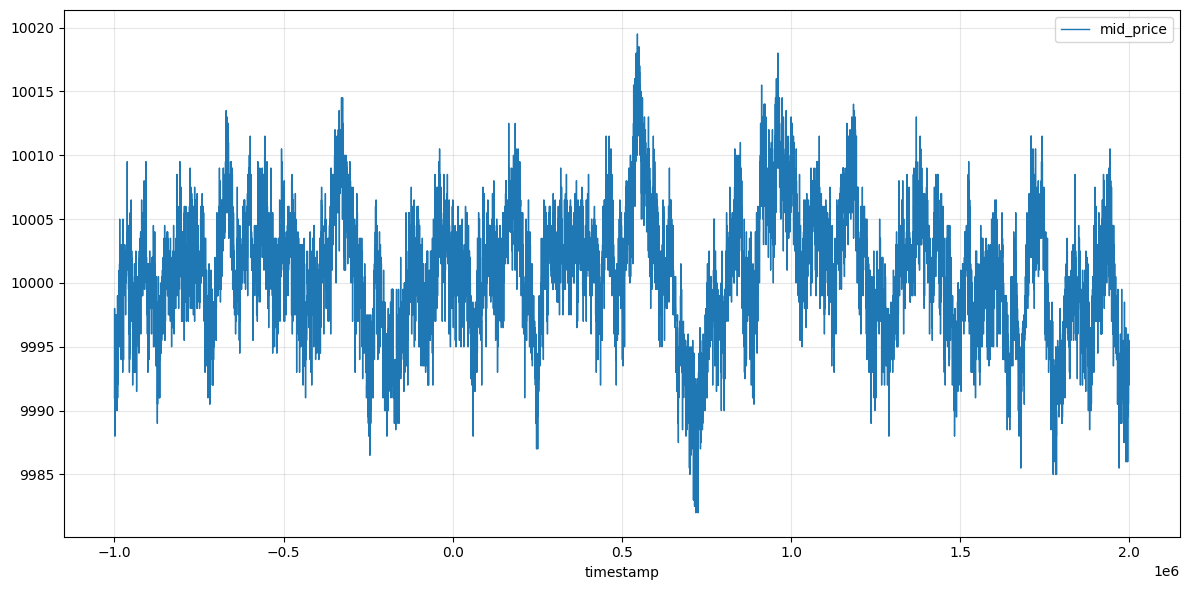

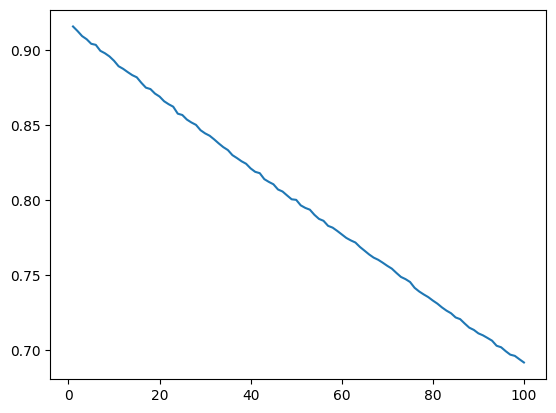

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string, json, math, statistics

from updated_tools import *

PRODUCT = "ASH_COATED_OSMIUM"

df = extract_data(2, 20000)
df = df[df["product"] == PRODUCT]
df_filtered = df[(df['bid_price_1'].notna()) & (df['ask_price_1'].notna())]
plot_mid_price(df_filtered)
plot_autocorrelation(df_filtered, 100)

In [31]:
# determine what the mean / std of deviation looks like
diff_list = list(df_filtered["mid_price"] - df_filtered["mid_price"].shift(1))
diff_list = np.array(diff_list)
diff_list = diff_list[~np.isnan(diff_list)]
print(f"deviation: mean = {diff_list.mean()}, \tstd = {diff_list.std()}")

# determine what the mean / std of mid_price looks like
a = df_filtered["mid_price"].mean()
b = df_filtered["mid_price"].std()
print(f"mid_price: mean = {a}, \t\tstd = {b}")

deviation: mean = 7.218392463998267e-05, 	std = 1.8815963824919284
mid_price: mean = 10000.853435830806, 		std = 4.58992905872975


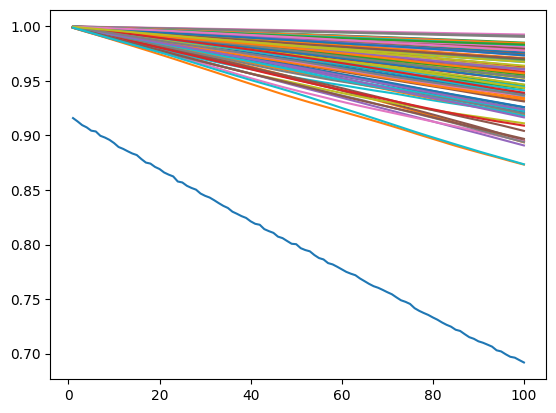

In [22]:
# determine if that autocorrelation is normal...

for _ in range(100):
    # generate normally_generated data
    normal_generate_data = [0]
    for i in range(9999):
        deviation = float(np.random.normal(loc = 0, scale = 1.88))
        normal_generate_data.append(normal_generate_data[-1] + deviation)
        normal_generate_data[-1] = round(normal_generate_data[-1])
    
    # make a df that has timestamps 1e6 to 1.99e6 + mid_price as data
    fake_df = pd.DataFrame({
        "timestamp": np.arange(1_000_000, 2_000_000, 100),
        "mid_price": normal_generate_data
    })
    
    # plot the autocorrelation
    plot_autocorrelation(fake_df, max_lag = 100)

plot_autocorrelation(df_filtered, 100)
plt.show()